In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from random import randrange
import random

class Chebyshev:
    """
    Chebyshev(a, b, n, func)
    Given a function func, lower and upper limits of the interval [a,b],
    and maximum degree n, this class computes a Chebyshev approximation
    of the function.
    Method eval(x) yields the approximated function value.
    """
    def __init__(self, a, b, n, func):
        n = n + 1
        self.a = a
        self.b = b
        self.func = func

        bma = 0.5 * (b - a)
        bpa = 0.5 * (b + a)
        f = [func(math.cos(math.pi * (k + 0.5) / n) * bma + bpa) for k in range(n)]
        self.roots = f

        self.x = [math.cos(math.pi * (k + 0.5) / n) * bma + bpa for k in range(n)]

        fac = 2.0 / n
        self.c = [fac * sum([f[k] * math.cos(math.pi * j * (k + 0.5) / n)
                  for k in range(n)]) for j in range(n)]

    def eval(self, x):
        a,b = self.a, self.b
        #assert(a <= x <= b)
        y = (2.0 * x - a - b) * (1.0 / (b - a))
        y2 = 2.0 * y
        (d, dd) = (self.c[-1], 0)             # Special case first step for efficiency
        for cj in self.c[-2:0:-1]:            # Clenshaw's recurrence
            (d, dd) = (y2 * d - dd + cj, d)
        return y * d - dd + 0.5 * self.c[0]   # Last step is different

In [2]:
import numpy as np
import math

def trig_poly_round_sqrt():
    N = 256
    seq = np.array([round(math.sqrt(i)) for i in range(N)], dtype=float)
    
    c = np.fft.fft(seq)  # tutti N coefficienti complessi

    def f(x):
        s = 0.0
        for k in range(N):
            ang = 2 * math.pi * k * x / N
            s += c[k].real * math.cos(ang) - c[k].imag * math.sin(ang)
        return s / N

    return f

f = trig_poly_round_sqrt()

# Verifica sui punti di interpolazione
print("Verifica interpolazione:")
for x in [0, 1, 2, 3, 4, 9, 16, 25, 100, 144, 225, 256, 512]:
    val = f(x)
    expected = math.sqrt(x)
    print(f"  x={x:3d}: f(x)={val:.6f}, sqrt(x)={expected:.6f}, err={abs(val-expected):.2e}")

Verifica interpolazione:
  x=  0: f(x)=-0.000000, sqrt(x)=0.000000, err=1.72e-15
  x=  1: f(x)=1.000000, sqrt(x)=1.000000, err=6.88e-15
  x=  2: f(x)=1.000000, sqrt(x)=1.414214, err=4.14e-01
  x=  3: f(x)=2.000000, sqrt(x)=1.732051, err=2.68e-01
  x=  4: f(x)=2.000000, sqrt(x)=2.000000, err=4.88e-15
  x=  9: f(x)=3.000000, sqrt(x)=3.000000, err=5.33e-15
  x= 16: f(x)=4.000000, sqrt(x)=4.000000, err=1.33e-15
  x= 25: f(x)=5.000000, sqrt(x)=5.000000, err=7.99e-15
  x=100: f(x)=10.000000, sqrt(x)=10.000000, err=4.80e-14
  x=144: f(x)=12.000000, sqrt(x)=12.000000, err=1.44e-13
  x=225: f(x)=15.000000, sqrt(x)=15.000000, err=5.33e-14
  x=256: f(x)=-0.000000, sqrt(x)=16.000000, err=1.60e+01
  x=512: f(x)=-0.000000, sqrt(x)=22.627417, err=2.26e+01


In [8]:
def invsqrt(x):
    return 1/np.sqrt(x)

In [99]:
c = Chebyshev(1, 1024, 800, invsqrt)

8.01581023779363e-14

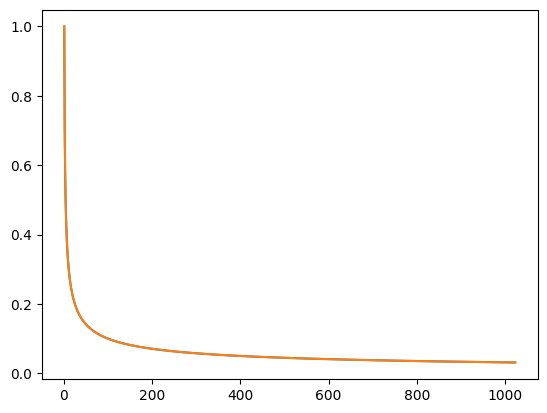

In [100]:
x = np.arange(1, 1024, 1)

y = np.vectorize(c.eval)(x)
y_real = np.vectorize(invsqrt)(x)

plt.plot(x, y)
plt.plot(x, y_real)

max(abs(y - y_real))

In [120]:
val = random.getrandbits(128)
val = 439304431412341

In [121]:
val.bit_length()

49

In [128]:
val2 = val >> (val.bit_length() - 10)
c.eval(val2) * 2**(val.bit_length() - 10)

19448962602.475536

In [131]:
val2

799

In [124]:
c.eval(val2)

0.035377456883862644

In [133]:
c.eval(val2) * 100

3.5377456883862646

In [ ]:
def inv_sqrt_newton(n, iters=5):
    y = 1.0 / (n ** 0.5)
    for _ in range(iters):
        y = y * (3.0 - n * y * y) * 0.5
    return y

In [134]:
def inv_sqrt_q64(n, iters=5):
    F = 64
    one = 1 << F

    # inizializzazione grezza (meglio se migliorabile)
    y = one

    for _ in range(iters):
        y2 = (y * y) >> F
        t = (n * y2) >> F
        y = (y * (3 * one - t)) >> 1

    return y

In [136]:
1 << 64

18446744073709551616

In [137]:
inv_sqrt_q64(val) / 2**64

OverflowError: integer division result too large for a float

In [130]:
(1/math.sqrt(val2))

0.03537745688386125

In [126]:
math.isqrt(val)

20959590

In [112]:
2**(val.bit_length() - 10)

1

In [ ]:
val * 2**(val.bit_length() - 10)

In [ ]:
x = (n >> (k - 10))

In [230]:
def sqrt_ckks(x):
    if x == 0:
        return 0
    k = max(0, (x.bit_length() - 8 + 1) // 2)  # non "- b + 1 + 1"
    y = x >> (2 * k)
    return (1 << k) * c.eval(y)

In [242]:
def isqrt_newton(n, iters = 5, hint = 0):
    if n < 0:
        raise ValueError("n deve essere non negativo")
    if n == 0:
        return 0
    
    # Stima iniziale: potenza di 2 più vicina
    if (hint == 0):
        x = 2**64
    else:
        x = hint
    
    for _ in range(iters):
        x = (x + n // x) >> 1 
    return x

In [244]:
abs(round(math.isqrt(val)) - isqrt_newton(val, 10))

0

In [245]:
abs(round(math.isqrt(val)) - isqrt_newton(val, 4, int(round(sqrt_ckks(val)))))

0

### Notes

- Prove the minumum amont of iterations given our Chebyshev hint
- I conjecture around 4, which means that under the flexible-ckks framework we require 4 mults (20 sec * 4) plus a 871 degree cheby eval (around 10 secs?). 

- Extra: we can do it for 4 elements in parallel, i conjecture that if we only require 1 element, we might speed up runtimes even further (maybe 15 secs per mult?). In jonathan work it takes like 8/9 minutes if im not wrong, so we are already winning here by like 9x times

In [9]:
def isqrt_bitwise(n, hint = 0):
    x = 0
    
    if hint == 0:
        bit = 1 << (2 * ((n.bit_length() - 1) // 2))
    else:
        bit = hint

    while bit:
        print("Iter")
        y = x + bit
        x >>= 1

        if y <= n:
            n -= y
            x += bit

        bit >>= 2

    return x

In [16]:
isqrt_bitwise(val)

Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter
Iter


10990485847579200948

In [15]:
math.sqrt(val)

1.0990485847579202e+19

In [142]:
val

439304431412341

In [166]:
def isqrt_nr(x, iters=30):
    if x == 0:
        return 0

    F = 32
    SCALE = 1 << F

    k = max(0, (x.bit_length() - 8 + 1) // 2)

    y = x >> (2 * k)

    # LUT: SCALE / sqrt(y)
    r = int(round(SCALE / c.eval(y)))

    for _ in range(iters):
        rr = (r * r) >> F
        t  = (y * rr) >> F
        r  = (r * ((3 << F) - t)) >> (F + 1)

    sqrt_y = (y * r) >> F

    return sqrt_y << k

In [167]:
isqrt_nr(val)

1367498293248

In [168]:
math.isqrt(val)

20959590

In [179]:
import math

F = 32
SCALE = 1 << F

table = [
    0 if i == 0 else round(SCALE / math.sqrt(i))
    for i in range(256)
]

def isqrt_nr(x, iters=5):
    if x == 0:
        return 0

    k = max(0, (x.bit_length() - 8 + 1) // 2)

    y = x >> (2 * k)

    # r ≈ SCALE / sqrt(y)
    r = table[y]

    for _ in range(iters):
        u = (y * r * r) >> F
        r = (r * ((3 << F) - u)) >> (F + 1)

    # sqrt(y)
    s = (y * r) >> F

    return s << k

In [180]:
isqrt_nr(val, 1)

18874368

In [181]:
math.isqrt(val)

20959590